In [27]:
project_root = "U:/ML_project/bargh"


In [29]:
import pandas as pd
import os



In [ ]:
import pandas as pd
import os
from src.crawler.crawl import ForecastCrawler
from src.data.data_cleaning import RawData
from src.models.filter_data.feature_adder import Feature_adder
from src.models.train_model.train_model import *



ForecastCrawler(file=RawData.PLANT.value).crawl()

commitment_path = os.path.join(project_root, "data", "interim", "commitment.csv")
commitment_df = pd.read_csv(commitment_path)

weather_forecast_path = os.path.join(project_root, "data", "interim", "weather_forecast.csv")
weather_forecast_df = pd.read_csv(weather_forecast_path)
weather_forecast_df = weather_forecast_df.rename(
    columns={'temperature_2m': 'temperature', 'relative_humidity_2m': 'humidity', 'dew_point_2m': 'dew', "time": 'hour',
             'unitid': 'id'})
commitment_df = commitment_df[["id", "name", "code"]].drop_duplicates()


result = pd.merge(weather_forecast_df, commitment_df, on='id', how='left')
result['date'] = pd.to_datetime(result['date'])

xlsx_input_path = os.path.join(project_root, "src", "models", "prediction", "one_day_input.xlsx")
df = pd.read_excel(xlsx_input_path)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by="date")
final_input = pd.merge(df, result, on=['name', 'code', 'date', 'hour'], how='outer')

feature_adder = Feature_adder(final_input, add_label_column=False)
for feature in ["temperature", "humidity", "dew", "surface_pressure"]:
    for hour in [1, 5]:
        feature_adder.create_feature_with_delay(feature, hour, drop_null=False)

final_input.dropna(inplace=True)

base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                 "forecast", "status"]
features_with_lag = ["temperature", "humidity", "dew", "surface_pressure"]
hours_delay = [1, 5]
lag_features = [f"{feature}_with_{hour}_delay" for feature in features_with_lag for hour in hours_delay]
# lag_features.append("generation_with_24_delay")
time_features = ["hour", "day_of_week", "month", "season", "datetime"]
final_input["generation"] = 0
df_f_selected = select_dataset_features(final_input, base_features, lag_features, time_features, "generation")
feature_selector = Feature_selector(df_f_selected, target="generation")
Xs, ys, name_code_df = feature_selector.get_X_and_y(n_mimo=4)
Xs = Xs.reindex(columns=model_X_cols)
Xs = Xs.fillna(False).infer_objects(copy=False)

ys_pred = model.predict(Xs)
y_pred = get_y_inverse_mimo(df_f_selected, feature_selector, name_code_df, 4, ys_pred)

In [30]:
xlsx_input_path = os.path.join(project_root, "src", "models", "prediction", "one_day_input.xlsx")
df = pd.read_excel(xlsx_input_path, nrows=1000)


In [4]:
df.head(30)

,name,code,date,hour,value,forecast,status
0,پرند,G11,2025-09-29,1,L,29288,SO
1,پرند,G11,2025-09-29,2,L,28138,SO
2,پرند,G11,2025-09-29,3,L,27300,SO
3,پرند,G11,2025-09-29,4,L,26788,SO
4,پرند,G11,2025-09-29,5,L,26500,SO
5,پرند,G11,2025-09-29,6,L,26298,SO
6,پرند,G11,2025-09-29,7,L,24876,SO
7,پرند,G11,2025-09-29,8,L,24871,SO
8,پرند,G11,2025-09-29,9,L,24892,SO
9,پرند,G11,2025-09-29,10,M,25669,SO


In [32]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by="date")

In [33]:
from src.crawler.crawl import ForecastCrawler
from src.data.data_cleaning import RawData

In [39]:
ForecastCrawler(file=RawData.PLANT.value).crawl()

2025-09-28 17:34:43 - Crawler - INFO - Plants data successfully read from U:\ML_project\bargh/data/raw/PlantData.csv
2025-09-28 17:34:43 - Crawler - INFO - Successfully read data from crawling config file
2025-09-28 17:34:43 - Crawler - INFO - Data with latitude:  29.37 and longitude:  52.61 added to the dataframe
2025-09-28 17:34:43 - Crawler - INFO - Data with latitude:  27.41 and longitude:  52.78 added to the dataframe
2025-09-28 17:34:43 - Crawler - INFO - Data with latitude:  37.34 and longitude:  58.05 added to the dataframe
2025-09-28 17:34:43 - Crawler - INFO - Data with latitude:  31.95 and longitude:  54.06 added to the dataframe
2025-09-28 17:34:43 - Crawler - INFO - Data with latitude:  37.35 and longitude:  45.27 added to the dataframe
2025-09-28 17:34:43 - Crawler - INFO - Data with latitude:  38.53 and longitude:  48.20 added to the dataframe
2025-09-28 17:34:43 - Crawler - INFO - Data with latitude:  32.80 and longitude:  51.50 added to the dataframe
2025-09-28 17:34:4

In [40]:
commitment_path = os.path.join(project_root, "data", "interim", "commitment.csv")
commitment_df = pd.read_csv(commitment_path)
weather_forecast_path = os.path.join(project_root, "data", "interim", "weather_forecast.csv")
weather_forecast_df = pd.read_csv(weather_forecast_path)

In [41]:
weather_forecast_df

,unitid,date,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,surface_pressure,evapotranspiration,wind_speed_10m,wind_direction_10m
0,917,2025-09-28,12,28.375000,12.0,-3.769452,21.989372,0.0,0.0,0.0,854.51807,0.02,25.764534,277.22420
1,917,2025-09-28,13,27.074999,13.0,-3.714837,20.897467,0.0,0.0,0.0,854.06690,0.02,24.291330,276.80896
2,917,2025-09-28,14,25.224998,15.0,-3.262853,19.727940,0.0,0.0,0.0,853.51290,0.01,20.008356,278.27582
3,917,2025-09-28,15,23.324999,20.0,-0.907469,18.828028,0.0,0.0,0.0,853.09210,0.01,15.328561,279.46225
4,917,2025-09-28,16,21.925000,26.0,1.545059,18.418910,0.0,0.0,0.0,852.99080,0.01,11.183201,273.69130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,104,2025-09-29,19,19.480999,31.0,1.900072,16.621399,0.0,0.0,0.0,894.21075,0.01,7.172949,342.47433
464,104,2025-09-29,20,17.931000,36.0,2.639273,15.186380,0.0,0.0,0.0,893.89140,0.01,7.289445,327.09476
465,104,2025-09-29,21,16.880999,38.0,2.466918,13.959724,0.0,0.0,0.0,893.75730,0.01,8.287822,325.61960
466,104,2025-09-29,22,15.631001,42.0,2.754925,12.706602,0.0,0.0,0.0,893.19040,0.01,8.669949,318.36655


In [42]:
weather_forecast_df = weather_forecast_df.rename(columns={'temperature_2m': 'temperature', 'relative_humidity_2m': 'humidity', 'dew_point_2m': 'dew', "time": 'hour', 'unitid': 'id'})


In [43]:
weather_forecast_df

,id,date,hour,temperature,humidity,dew,apparent_temperature,precipitation,rain,snowfall,surface_pressure,evapotranspiration,wind_speed_10m,wind_direction_10m
0,917,2025-09-28,12,28.375000,12.0,-3.769452,21.989372,0.0,0.0,0.0,854.51807,0.02,25.764534,277.22420
1,917,2025-09-28,13,27.074999,13.0,-3.714837,20.897467,0.0,0.0,0.0,854.06690,0.02,24.291330,276.80896
2,917,2025-09-28,14,25.224998,15.0,-3.262853,19.727940,0.0,0.0,0.0,853.51290,0.01,20.008356,278.27582
3,917,2025-09-28,15,23.324999,20.0,-0.907469,18.828028,0.0,0.0,0.0,853.09210,0.01,15.328561,279.46225
4,917,2025-09-28,16,21.925000,26.0,1.545059,18.418910,0.0,0.0,0.0,852.99080,0.01,11.183201,273.69130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,104,2025-09-29,19,19.480999,31.0,1.900072,16.621399,0.0,0.0,0.0,894.21075,0.01,7.172949,342.47433
464,104,2025-09-29,20,17.931000,36.0,2.639273,15.186380,0.0,0.0,0.0,893.89140,0.01,7.289445,327.09476
465,104,2025-09-29,21,16.880999,38.0,2.466918,13.959724,0.0,0.0,0.0,893.75730,0.01,8.287822,325.61960
466,104,2025-09-29,22,15.631001,42.0,2.754925,12.706602,0.0,0.0,0.0,893.19040,0.01,8.669949,318.36655


In [44]:
commitment_df = commitment_df[["id", "name", "code"]].drop_duplicates()
commitment_df

,id,name,code
0,104,پرند,G11
35064,104,پرند,G12
47544,104,پرند,G13
60024,104,پرند,G14
72504,104,پرند,G15
...,...,...,...
1527888,917,حافظ,G12
1540368,917,حافظ,G13
1552848,917,حافظ,G14
1565328,917,حافظ,G15


In [47]:
result = pd.merge(weather_forecast_df, commitment_df, on='id', how='left')
result['date'] = pd.to_datetime(result['date'])
result

,id,date,hour,temperature,humidity,dew,apparent_temperature,precipitation,rain,snowfall,surface_pressure,evapotranspiration,wind_speed_10m,wind_direction_10m,name,code
0,917,2025-09-28,12,28.375,12.0,-3.769452,21.989372,0.0,0.0,0.0,854.51807,0.02,25.764534,277.22420,حافظ,G11
1,917,2025-09-28,12,28.375,12.0,-3.769452,21.989372,0.0,0.0,0.0,854.51807,0.02,25.764534,277.22420,حافظ,G12
2,917,2025-09-28,12,28.375,12.0,-3.769452,21.989372,0.0,0.0,0.0,854.51807,0.02,25.764534,277.22420,حافظ,G13
3,917,2025-09-28,12,28.375,12.0,-3.769452,21.989372,0.0,0.0,0.0,854.51807,0.02,25.764534,277.22420,حافظ,G14
4,917,2025-09-28,12,28.375,12.0,-3.769452,21.989372,0.0,0.0,0.0,854.51807,0.02,25.764534,277.22420,حافظ,G15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3883,104,2025-09-29,23,14.781,45.0,2.958145,11.858799,0.0,0.0,0.0,892.51025,0.01,8.913181,316.63654,پرند,G15
3884,104,2025-09-29,23,14.781,45.0,2.958145,11.858799,0.0,0.0,0.0,892.51025,0.01,8.913181,316.63654,پرند,G16
3885,104,2025-09-29,23,14.781,45.0,2.958145,11.858799,0.0,0.0,0.0,892.51025,0.01,8.913181,316.63654,پرند,S1
3886,104,2025-09-29,23,14.781,45.0,2.958145,11.858799,0.0,0.0,0.0,892.51025,0.01,8.913181,316.63654,پرند,S2


In [48]:
final_input = pd.merge(df, result, on=['name', 'code', 'date', 'hour'], how='outer')

In [49]:
final_input

,name,code,date,hour,value,forecast,status,id,temperature,humidity,dew,apparent_temperature,precipitation,rain,snowfall,surface_pressure,evapotranspiration,wind_speed_10m,wind_direction_10m
0,جنوب اصفهان - چهلستون,G11,2025-09-28,12,NaN,NaN,NaN,406.0,29.349500,13.0,-1.931025,25.381493,0.0,0.0,0.0,835.19360,0.01,10.703569,47.72637
1,جنوب اصفهان - چهلستون,G11,2025-09-28,13,NaN,NaN,NaN,406.0,28.899500,13.0,-2.283672,25.442215,0.0,0.0,0.0,834.87690,-0.00,6.877789,47.12111
2,جنوب اصفهان - چهلستون,G11,2025-09-28,14,NaN,NaN,NaN,406.0,27.849500,14.0,-2.106934,24.033092,0.0,0.0,0.0,834.57544,-0.00,9.504272,37.30404
3,جنوب اصفهان - چهلستون,G11,2025-09-28,15,NaN,NaN,NaN,406.0,26.099500,15.0,-2.564464,22.735308,0.0,0.0,0.0,833.98240,-0.00,5.991594,32.73523
4,جنوب اصفهان - چهلستون,G11,2025-09-28,16,NaN,NaN,NaN,406.0,25.049500,17.0,-1.713291,22.463457,0.0,0.0,0.0,834.00030,-0.00,1.440000,180.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3884,گیلان,S3,2025-09-29,19,NaN,NaN,NaN,232.0,19.417501,96.0,18.762684,22.385983,0.0,0.0,0.0,1010.11993,-0.00,2.036468,224.99990
3885,گیلان,S3,2025-09-29,20,NaN,NaN,NaN,232.0,18.917501,98.0,18.594261,21.652930,0.0,0.0,0.0,1009.51556,-0.00,3.096837,215.53777
3886,گیلان,S3,2025-09-29,21,NaN,NaN,NaN,232.0,18.217500,100.0,18.217500,20.644464,0.0,0.0,0.0,1009.10820,-0.00,4.024922,190.30480
3887,گیلان,S3,2025-09-29,22,NaN,NaN,NaN,232.0,17.517500,100.0,17.517502,19.795507,0.0,0.0,0.0,1008.50130,0.00,2.902413,187.12492


In [50]:
from src.models.filter_data.feature_adder import Feature_adder

feature_adder = Feature_adder(final_input, add_label_column=False)
for feature in ["temperature", "humidity", "dew", "surface_pressure"]:
    for hour in [1, 5]:
        feature_adder.create_feature_with_delay(feature, hour, drop_null=False)


In [51]:
final_input

,name,code,date,hour,value,forecast,status,id,temperature,humidity,...,day_of_week,month,temperature_with_1_delay,temperature_with_5_delay,humidity_with_1_delay,humidity_with_5_delay,dew_with_1_delay,dew_with_5_delay,surface_pressure_with_1_delay,surface_pressure_with_5_delay
0,جنوب اصفهان - چهلستون,G11,2025-09-28,12,NaN,NaN,NaN,406.0,29.349500,13.0,...,6,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,جنوب اصفهان - چهلستون,G11,2025-09-28,13,NaN,NaN,NaN,406.0,28.899500,13.0,...,6,9,29.349500,NaN,13.0,NaN,-1.931025,NaN,835.19360,NaN
2,جنوب اصفهان - چهلستون,G11,2025-09-28,14,NaN,NaN,NaN,406.0,27.849500,14.0,...,6,9,28.899500,NaN,13.0,NaN,-2.283672,NaN,834.87690,NaN
3,جنوب اصفهان - چهلستون,G11,2025-09-28,15,NaN,NaN,NaN,406.0,26.099500,15.0,...,6,9,27.849500,NaN,14.0,NaN,-2.106934,NaN,834.57544,NaN
4,جنوب اصفهان - چهلستون,G11,2025-09-28,16,NaN,NaN,NaN,406.0,25.049500,17.0,...,6,9,26.099500,NaN,15.0,NaN,-2.564464,NaN,833.98240,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3884,گیلان,S3,2025-09-29,19,NaN,NaN,NaN,232.0,19.417501,96.0,...,0,9,19.817501,21.767500,94.0,88.0,18.823225,19.691252,1010.52356,1011.64450
3885,گیلان,S3,2025-09-29,20,NaN,NaN,NaN,232.0,18.917501,98.0,...,0,9,19.417501,21.067501,96.0,92.0,18.762684,19.716679,1010.11993,1011.53595
3886,گیلان,S3,2025-09-29,21,NaN,NaN,NaN,232.0,18.217500,100.0,...,0,9,18.917501,20.417501,98.0,94.0,18.594261,19.418690,1009.51556,1011.22850
3887,گیلان,S3,2025-09-29,22,NaN,NaN,NaN,232.0,17.517500,100.0,...,0,9,18.217500,20.167501,100.0,94.0,18.217500,19.170582,1009.10820,1010.82690


In [52]:
final_input.dropna(inplace=True)

In [54]:
from src.models.train_model.train_model import *

base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                 "forecast", "status"]
features_with_lag = ["temperature", "humidity", "dew", "surface_pressure"]
hours_delay = [1, 5]
lag_features = [f"{feature}_with_{hour}_delay" for feature in features_with_lag for hour in hours_delay]
# lag_features.append("generation_with_24_delay")
time_features = ["hour", "day_of_week", "month", "season", "datetime"]
final_input["generation"] = 0
df_f_selected = select_dataset_features(final_input, base_features, lag_features, time_features, "generation")

save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")

with open(f"{save_model_folder}/model_cols.pkl", 'rb') as f:
    model_X_cols = load(f)
    
model = load_model(save_model_folder)
feature_selector = Feature_selector(df_f_selected, target="generation")
Xs, ys, name_code_df = feature_selector.get_X_and_y(n_mimo=4)
Xs = Xs.reindex(columns=model_X_cols)
Xs = Xs.fillna(False).infer_objects(copy=False)

ys_pred = model.predict(Xs)
y_pred = get_y_inverse_mimo(df_f_selected, feature_selector, name_code_df, 4, ys_pred)
y_test = get_y_inverse_mimo(df_f_selected, feature_selector, name_code_df, 4, ys)

2025-09-28 17:41:00 - train_model - INFO - Some features have been dropped successfully
C:\Users\S.H.Jasbi\AppData\Local\Temp\ipykernel_7348\3747105184.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Xs = Xs.fillna(False).infer_objects(copy=False)


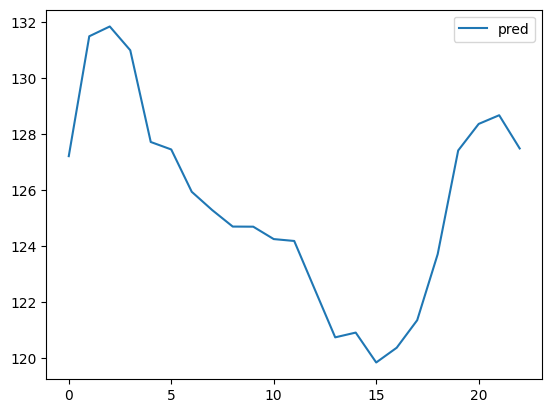

In [55]:
import matplotlib.pyplot as plt

plt.plot(y_pred, label="pred")
plt.legend()
plt.show()